In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA



In [63]:
df = pd.read_csv("D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\pokemon_complete_2025.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\acer\AppData\Local\Temp\ipykernel_28192\2479942647.py:1: SyntaxWarning: invalid escape sequence '\K'
  df = pd.read_csv("D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\pokemon_complete_2025.csv")


,pokedex_id,name,genus,generation,type_1,type_2,num_types,hp,attack,defense,...,sprite_url,is_dual_type,bmi,attack_defense_ratio,physical_total,special_total,offensive_total,defensive_total,gender_distribution,stat_tier
0,1,bulbasaur,Seed Pokémon,I,grass,poison,2,45,49,49,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,14.1,1.00,98,130,159,159,88% Male / 12% Female,Below Average (300-399)
1,2,ivysaur,Seed Pokémon,I,grass,poison,2,60,62,63,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,13.0,0.98,125,160,202,203,88% Male / 12% Female,Average (400-499)
2,3,venusaur,Seed Pokémon,I,grass,poison,2,80,82,83,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,25.0,0.99,165,200,262,263,88% Male / 12% Female,Strong (500-599)
3,4,charmander,Lizard Pokémon,I,fire,NaN,1,39,52,43,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,23.6,1.21,95,110,177,132,88% Male / 12% Female,Below Average (300-399)
4,5,charmeleon,Flame Pokémon,I,fire,NaN,1,58,64,58,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,15.7,1.10,122,145,224,181,88% Male / 12% Female,Average (400-499)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,1021,raging-bolt,Paradox Pokémon,IX,electric,dragon,2,125,73,91,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,17.8,0.80,164,226,285,305,Genderless,Strong (500-599)
1021,1022,iron-boulder,Paradox Pokémon,IX,rock,psychic,2,90,120,80,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,72.2,1.50,200,176,312,278,Genderless,Strong (500-599)
1022,1023,iron-crown,Paradox Pokémon,IX,steel,psychic,2,90,72,100,...,https://raw.githubusercontent.com/PokeAPI/spri...,True,60.9,0.72,172,230,292,298,Genderless,Strong (500-599)
1023,1024,terapagos,Tera Pokémon,IX,normal,NaN,1,90,65,85,...,https://raw.githubusercontent.com/PokeAPI/spri...,False,162.5,0.76,150,150,190,260,Genderless,Average (400-499)


In [64]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pokedex_id            1025 non-null   int64  
 1   name                  1025 non-null   object 
 2   genus                 1025 non-null   object 
 3   generation            1025 non-null   object 
 4   type_1                1025 non-null   object 
 5   type_2                526 non-null    object 
 6   num_types             1025 non-null   int64  
 7   hp                    1025 non-null   int64  
 8   attack                1025 non-null   int64  
 9   defense               1025 non-null   int64  
 10  sp_attack             1025 non-null   int64  
 11  sp_defense            1025 non-null   int64  
 12  speed                 1025 non-null   int64  
 13  base_stat_total       1025 non-null   int64  
 14  height_m              1025 non-null   float64
 15  weight_kg            

(1025, 43)

In [65]:
df.isnull().sum() 

pokedex_id                0
name                      0
genus                     0
generation                0
type_1                    0
type_2                  499
num_types                 0
hp                        0
attack                    0
defense                   0
sp_attack                 0
sp_defense                0
speed                     0
base_stat_total           0
height_m                  0
weight_kg                 0
base_experience           0
ability_1                 0
ability_2               495
hidden_ability          169
color                     0
shape                     0
habitat                 639
growth_rate               0
egg_groups                0
is_legendary              0
is_mythical               0
is_baby                   0
capture_rate              0
base_happiness            0
hatch_counter             0
gender_rate               0
description               0
sprite_url                0
is_dual_type              0
bmi                 

In [66]:
df.isnull().sum() / len(df) * 100

pokedex_id               0.000000
name                     0.000000
genus                    0.000000
generation               0.000000
type_1                   0.000000
type_2                  48.682927
num_types                0.000000
hp                       0.000000
attack                   0.000000
defense                  0.000000
sp_attack                0.000000
sp_defense               0.000000
speed                    0.000000
base_stat_total          0.000000
height_m                 0.000000
weight_kg                0.000000
base_experience          0.000000
ability_1                0.000000
ability_2               48.292683
hidden_ability          16.487805
color                    0.000000
shape                    0.000000
habitat                 62.341463
growth_rate              0.000000
egg_groups               0.000000
is_legendary             0.000000
is_mythical              0.000000
is_baby                  0.000000
capture_rate             0.000000
base_happiness

In [67]:
features = [
    'hp', 'attack', 'defense',
    'sp_attack', 'sp_defense', 'speed',
    'base_stat_total',
    'offensive_total', 'defensive_total',
    'height_m', 'weight_kg'
]

In [68]:
df = df[features]
df

,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,offensive_total,defensive_total,height_m,weight_kg
0,45,49,49,65,65,45,318,159,159,0.7,6.9
1,60,62,63,80,80,60,405,202,203,1.0,13.0
2,80,82,83,100,100,80,525,262,263,2.0,100.0
3,39,52,43,60,50,65,309,177,132,0.6,8.5
4,58,64,58,80,65,80,405,224,181,1.1,19.0
...,...,...,...,...,...,...,...,...,...,...,...
1020,125,73,91,137,89,75,590,285,305,5.2,480.0
1021,90,120,80,68,108,124,590,312,278,1.5,162.5
1022,90,72,100,122,108,98,590,292,298,1.6,156.0
1023,90,65,85,65,85,60,450,190,260,0.2,6.5


In [69]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

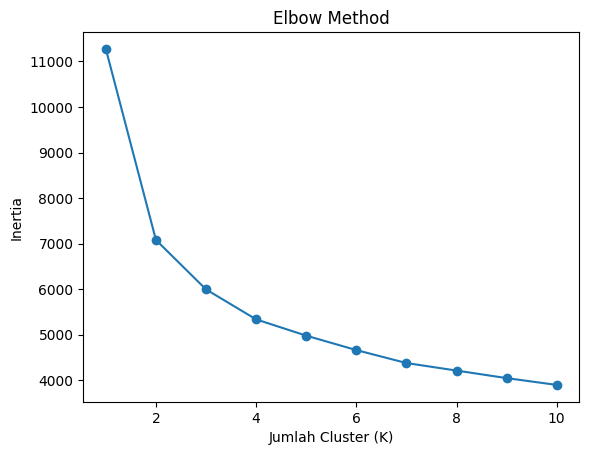

In [70]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [71]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.3399931788599544
K=3, Silhouette Score=0.3288599560269965
K=4, Silhouette Score=0.2676333672365866
K=5, Silhouette Score=0.1935668877697799
K=6, Silhouette Score=0.17481431053967425
K=7, Silhouette Score=0.18441493904579467
K=8, Silhouette Score=0.1538021618934314
K=9, Silhouette Score=0.15828171719934034
K=10, Silhouette Score=0.15416782410415647


In [72]:
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\acer\AppData\Local\Temp\ipykernel_28192\2887599789.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = kmeans.fit_predict(X_scaled)


In [73]:
print("Silhouette Score:", silhouette_score(X_scaled, df['cluster']))
print("Davies Bouldin Index:", davies_bouldin_score(X_scaled, df['cluster']))

Silhouette Score: 0.3399931788599544
Davies Bouldin Index: 1.104873822284567


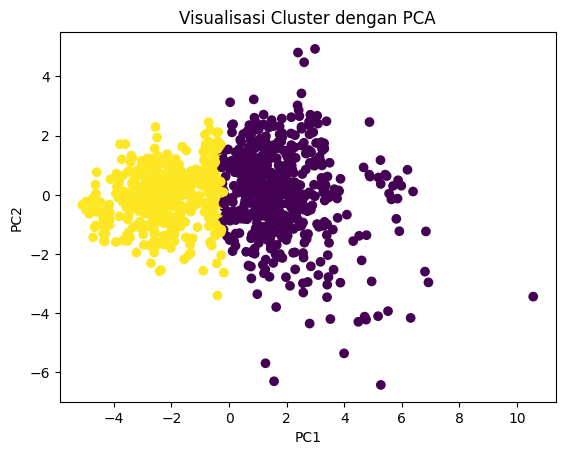

In [74]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisasi Cluster dengan PCA')
plt.show()

In [75]:
df.groupby('cluster').mean()

,hp,attack,defense,sp_attack,sp_defense,speed,base_stat_total,offensive_total,defensive_total,height_m,weight_kg
cluster,,,,,,,,,,,
0,84.200355,93.936170,87.849291,85.218085,85.021277,78.696809,514.921986,257.851064,257.070922,1.685816,107.425532
1,53.036876,57.440347,53.737527,51.561822,52.080260,53.104121,320.960954,162.106291,158.854664,0.631453,17.512364


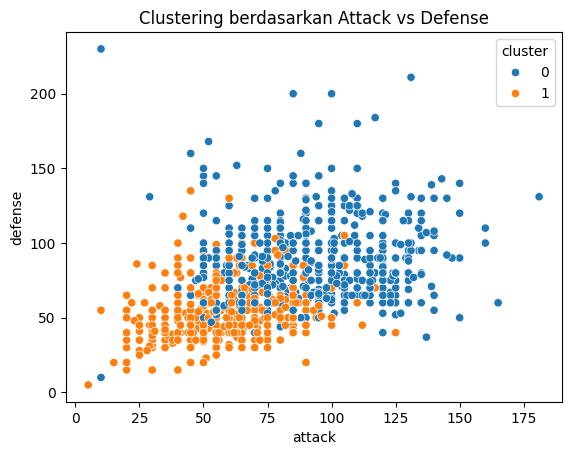

In [76]:
plt.figure()
sns.scatterplot(
    x=df['attack'],
    y=df['defense'],
    hue=df['cluster']
)
plt.title('Clustering berdasarkan Attack vs Defense')
plt.show()

<Axes: >

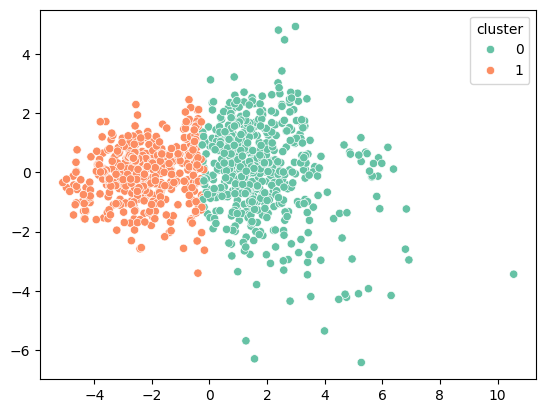

In [77]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette='Set2')